# **Cell Phone Price Range Prediction**
**Predicting the price range of a mobile phone based on its technical specifications**

---

## **Domain: Consumer Electronics / Mobile Market**

Bob has started his own mobile phone company and wants to compete with established brands such as **Apple** and **Samsung**. To price his devices competitively, he needs a data-driven approach to predict the appropriate price range of a mobile phone based on its technical specifications.

---
## **Abstract**

This project focuses on predicting the price range of mobile phones based on their technical specifications, including **RAM**, **battery power**, **pixel resolution**, and **processing capability**. Exploratory Data Analysis (EDA) was performed to understand data distribution and identify key feature relationships. Multiple machine learning classification models—such as **Logistic Regression**, **Decision Tree**, **Random Forest**, **Support Vector Machine (SVM)**, **k-Nearest Neighbors (k-NN)**, and **XGBoost**—were implemented and evaluated using comprehensive performance metrics.

Hyperparameter tuning was applied to optimize model performance, after which **XGBoost** emerged as the best-performing model based on **accuracy**, **F1-score**, and **ROC-AUC**. The findings provide valuable insights that can support mobile manufacturers in making informed decisions related to **pricing strategies**, **product positioning**, and **feature optimization**.


---

## **Problem Statement**

The objective of this project is to build a **machine learning classification model** that predicts the price range of a mobile phone using its hardware and technical features such as battery power, RAM, internal memory, pixel resolution, and connectivity options.

**Price Range Categories:**
- **0** → Low Cost  
- **1** → Medium Cost  
- **2** → High Cost  
- **3** → Very High Cost  

---

## **Dataset Information**

- **Total Records:** 2000  
- **Dataset Type:** Multiclass Classification  
- **Target Variable:** `price_range` (4 classes)  
- **Number of Features:** 20  
- **Feature Examples:** Battery Power, RAM, Bluetooth, Internal Memory, Pixel Resolution, Screen Size, etc.

---

## **Project Objectives**

- **Task 1:** Perform detailed **Exploratory Data Analysis (EDA)** to understand feature distributions and relationships.
- **Task 2:** Build and evaluate multiple **machine learning classification models** to predict the price range.
- **Task 3:** Derive **business insights and recommendations** based on feature importance and model performance.

---

## **Exploratory Data Analysis (EDA)**

The analysis begins with Exploratory Data Analysis to examine the target variable distribution, identify important features, and understand how different mobile phone specifications influence the price range.


# **Importing Required Libraries**
This section includes all the Python libraries required for data manipulation, visualization, and model building.


In [17]:
# Core Libraries
import warnings
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Warning Configuration
warnings.simplefilter(action="ignore", category=FutureWarning)


# **Load Dataset**
The dataset is loaded using Pandas to begin the data analysis process.


In [9]:
# Load the dataset
data = pd.read_csv("Cellphone Dataset.csv")


# **Basic Dataset Information**
This section provides an overview of the dataset structure, data types, and basic statistics.


In [18]:
# Dataset shape
print(f"Dataset Shape: {data.shape}")

# Dataset structure and data types
print("\nDataset Information:")
data.info()

# Missing values analysis
print("\nMissing Values Per Column:")
print(data.isnull().sum())

# Preview first few records
data.head()

# Statistical summary of numerical features
data.describe()


Dataset Shape: (2000, 21)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  thre

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


 ### **Missing Values Check**

- The dataset does not contain any missing values.

---

## **Target Variable Distribution**

### Let’s check whether the dataset is balanced across the four price range categories.


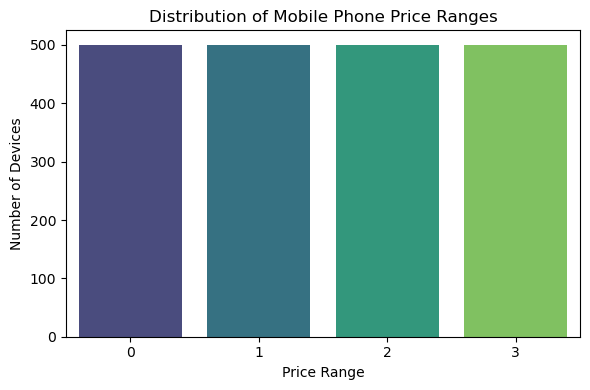

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x="price_range",
    data=data,
    palette="viridis"
)

plt.title("Distribution of Mobile Phone Price Ranges", fontsize=12)
plt.xlabel("Price Range", fontsize=10)
plt.ylabel("Number of Devices", fontsize=10)

plt.tight_layout()
plt.show()


### **Target Variable Distribution**

- The target variable **price_range** is well balanced across all four categories.
- Since there is no significant class imbalance, **resampling techniques are not required**.

---

# **Correlation Analysis**

#### Now, let’s analyze how each feature correlates with the target variable (**price_range**) to understand their influence on mobile phone pricing.


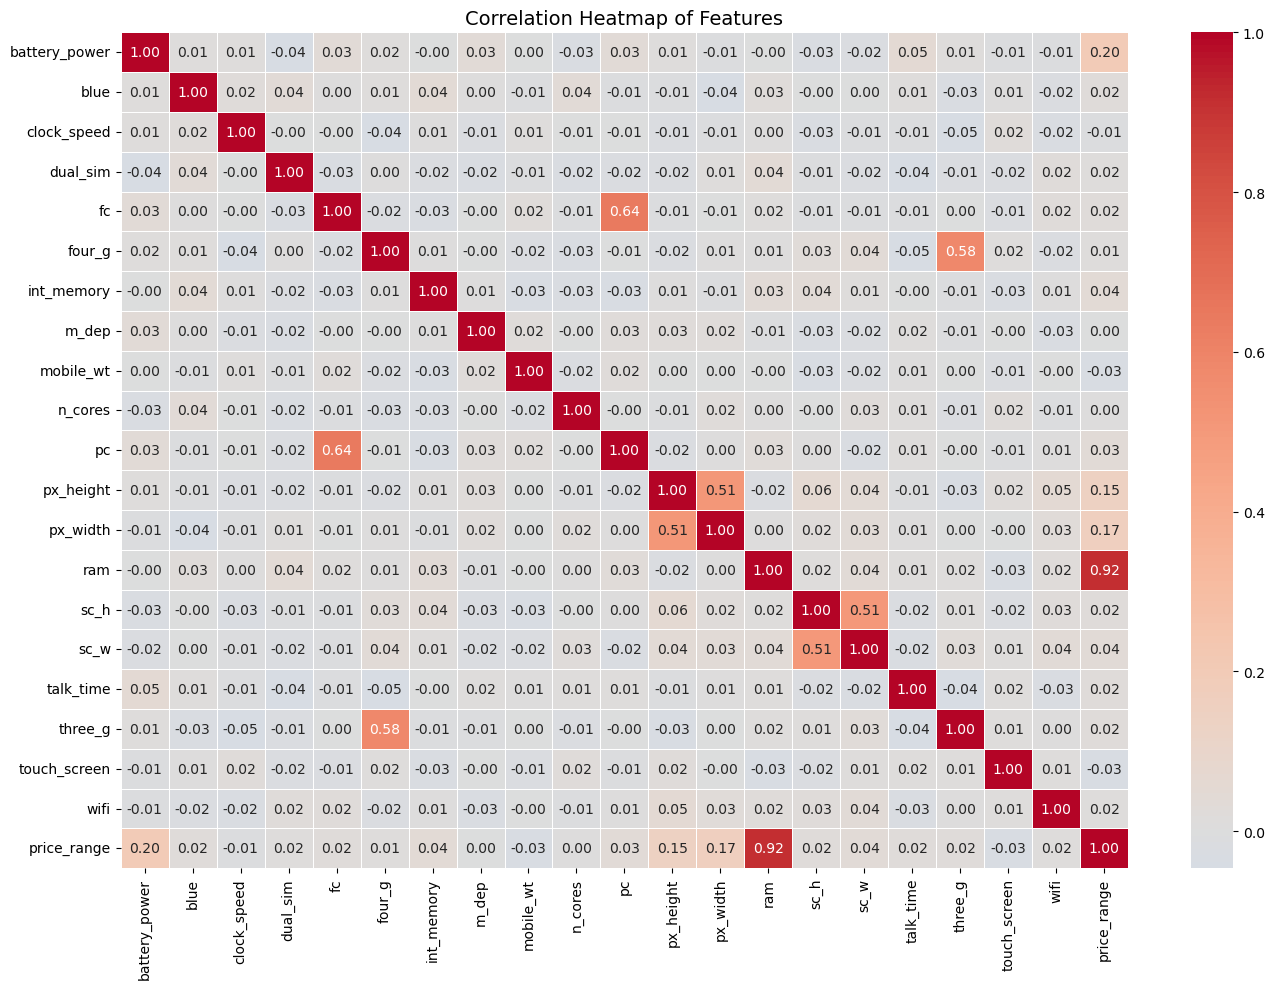

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

In [20]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

correlation_matrix = data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Features", fontsize=14)
plt.tight_layout()
plt.show()


# Correlation with target variable (price_range)
price_range_correlation = (
    correlation_matrix["price_range"]
    .sort_values(ascending=False)
)

price_range_correlation


### **Observations**

- **RAM (correlation ≈ 0.917)** is the most significant feature influencing the price range.
- **Battery Power**, **Pixel Width**, and **Pixel Height** show a moderate positive correlation with the target variable.
- Other features such as **clock_speed**, **mobile_wt**, and **dual_sim** have very weak individual correlation, but they may still contribute effectively in **non-linear models** like Random Forest or Gradient Boosting.


## **Feature vs Price Range Analysis**

This section explores how key features such as **RAM**, **Battery Power**, **Pixel Width**, and **Pixel Height** change across different price range categories, helping us understand their impact on pricing decisions.


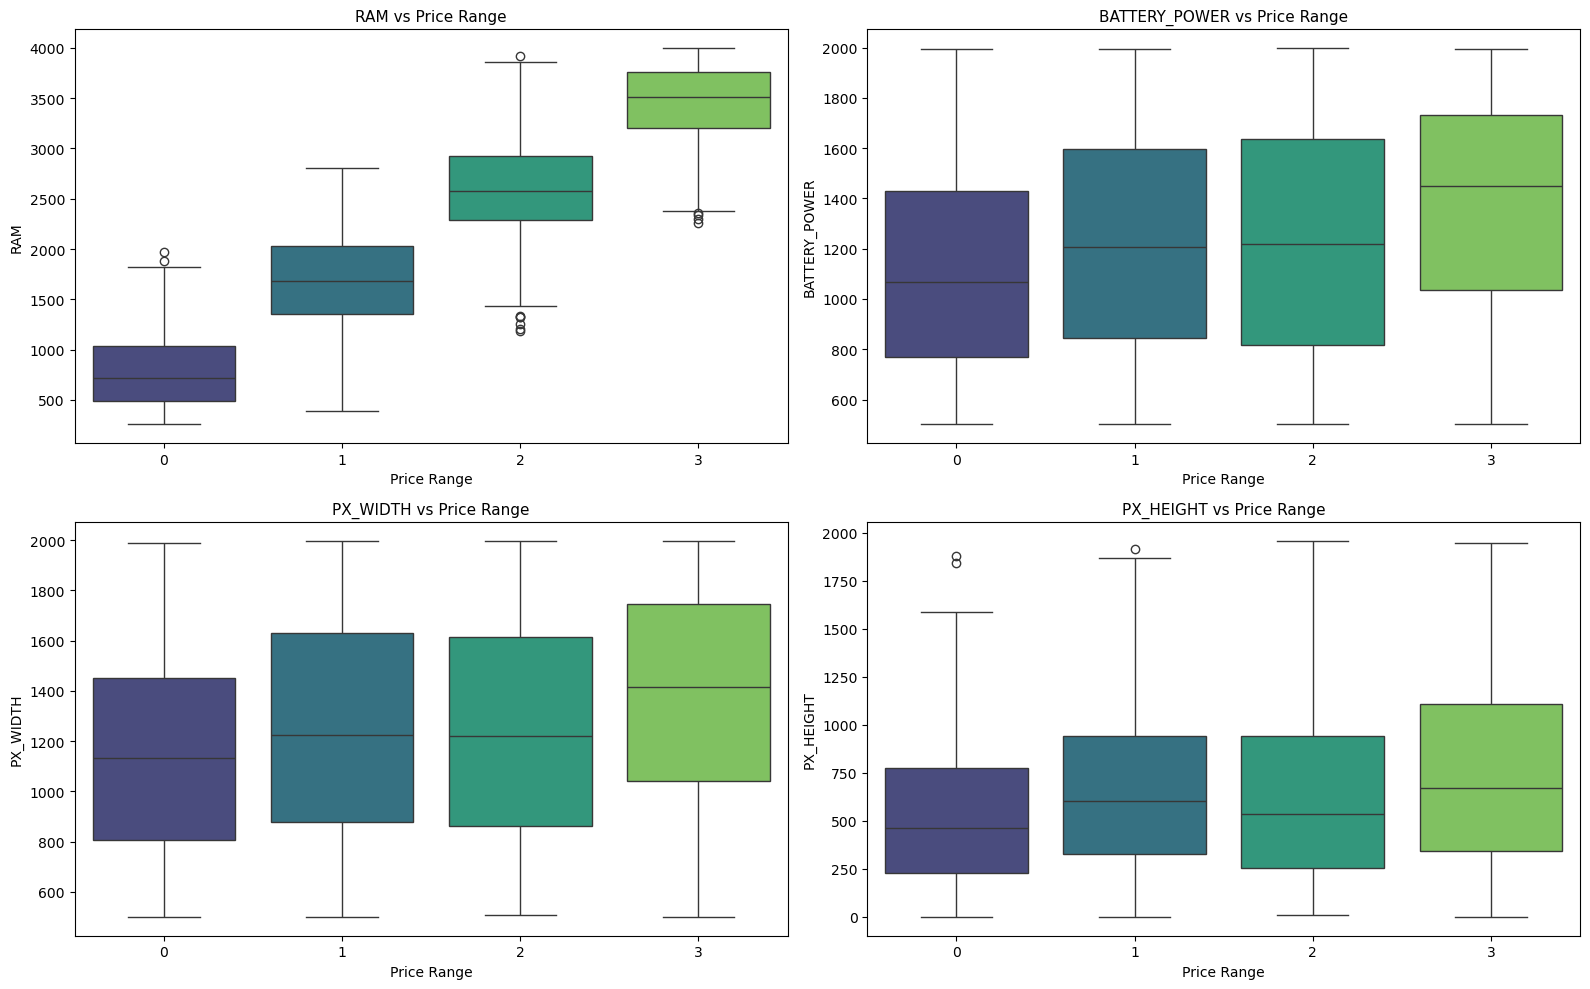

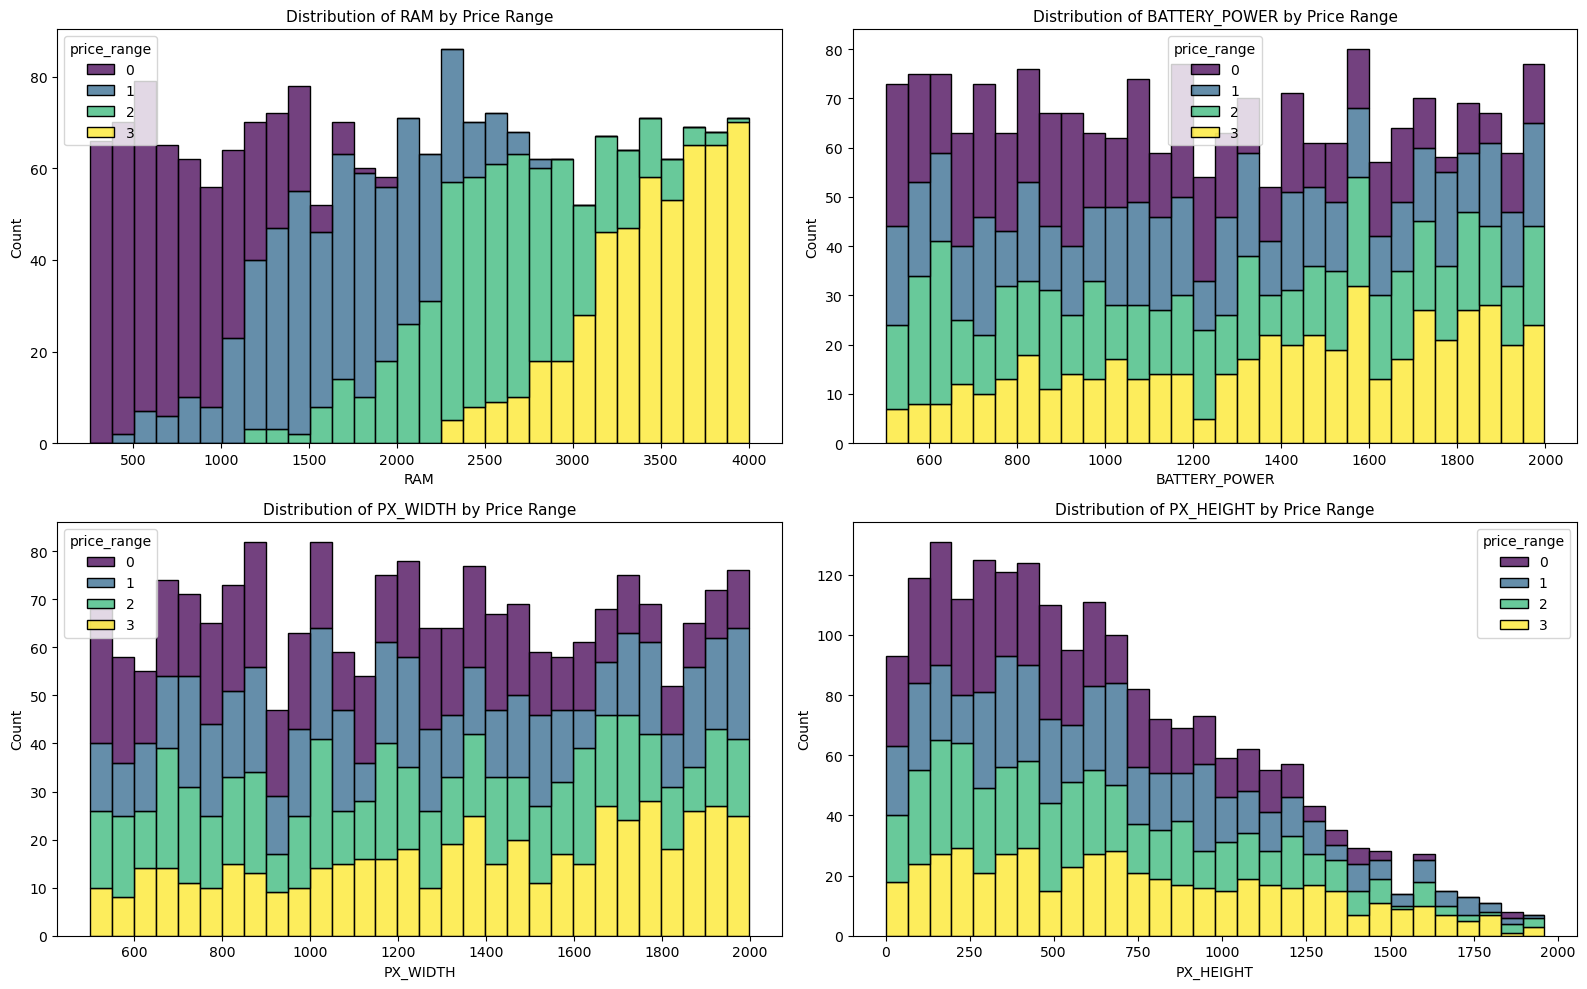

In [21]:
# Boxplots for top correlated features
top_features = ["ram", "battery_power", "px_width", "px_height"]

plt.figure(figsize=(16, 10))

for index, feature in enumerate(top_features, start=1):
    plt.subplot(2, 2, index)
    sns.boxplot(
        x="price_range",
        y=feature,
        data=data,
        palette="viridis"
    )
    plt.title(f"{feature.upper()} vs Price Range", fontsize=11)
    plt.xlabel("Price Range")
    plt.ylabel(feature.upper())

plt.tight_layout()
plt.show()


# Histograms for top correlated features
plt.figure(figsize=(16, 10))

for index, feature in enumerate(top_features, start=1):
    plt.subplot(2, 2, index)
    sns.histplot(
        data=data,
        x=feature,
        hue="price_range",
        multiple="stack",
        bins=30,
        palette="viridis"
    )
    plt.title(f"Distribution of {feature.upper()} by Price Range", fontsize=11)
    plt.xlabel(feature.upper())
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


## **Insights**

- **RAM** increases almost linearly with the price range, making it the most critical feature for price prediction.
- **Battery Power** shows a moderate upward trend as the price range increases.
- **Pixel Resolution** (both width and height) also tends to increase with higher price ranges, although the separation is less distinct compared to RAM.
- Other features may contribute to price prediction when combined with these top predictors, especially in non-linear models.

---
### **EDA Summary**

- **RAM** exhibits a strong positive relationship with the price range, making it the most influential feature.
- **Battery power** and **pixel resolution** also contribute significantly to differentiating mobile phone price categories.
- The target variable (**price_range**) is well balanced across all four price categories.
- No extreme outliers were identified that could negatively impact model performance.
---

## **Next Step: Data Preprocessing and Model Building**

In the next phase, the dataset will be split into **training and testing sets**, features will be **scaled**, and multiple **classification models** such as **Logistic Regression**, **Random Forest**, and **XGBoost** will be trained and evaluated.


## **Data Preprocessing**

Before building the machine learning models, the following preprocessing steps are performed:

- **Feature–Target Split:** Separate the independent variables (features) and the dependent variable (**price_range**).
- **Train–Test Split:** Divide the dataset into training and testing sets using an **80:20 ratio**.
- **Feature Scaling:** Standardize the feature values using **StandardScaler**, as models such as **Logistic Regression**, **SVM**, and **k-NN** are sensitive to differences in feature scales.
- **Class Balance Check:** Verify whether the dataset is balanced across all price range categories to determine if resampling techniques are required.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target variable
X = data.drop(columns=["price_range"])
y = data["price_range"]

# Check class distribution (to ensure balanced target classes)
print("Class Distribution (Proportion):")
print(y.value_counts(normalize=True))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Class Distribution (Proportion):
price_range
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64


## **Model Training and Evaluation**

The following machine learning classification models will be trained and evaluated to predict the mobile phone price range:

- **Logistic Regression**
- **Decision Tree Classifier**
- **Random Forest Classifier**
- **XGBoost Classifier**
- **Support Vector Machine (SVM)**
- **k-Nearest Neighbors (k-NN)**

Each model will be evaluated using appropriate performance metrics such as **accuracy**, **confusion matrix**, and **classification report** to compare their effectiveness.


## **Evaluation Metrics**

The performance of the classification models will be assessed using the following evaluation metrics:

- **Accuracy:** Measures the overall correctness of the model.
- **Precision:** Indicates how many of the predicted positive instances are actually correct.
- **Recall:** Measures the model’s ability to correctly identify all relevant instances.
- **F1-Score:** The harmonic mean of precision and recall, useful for evaluating imbalanced classes.
- **Confusion Matrix:** Provides a detailed breakdown of correct and incorrect predictions across all classes.
- **ROC-AUC (Macro):** Evaluates the model’s ability to distinguish between multiple classes by averaging the ROC-AUC score across all classes.


In [ ]:
pip install xgboost --user


In [28]:
from xgboost import XGBClassifier


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Define machine learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42
    ),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

results = []

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    roc_auc = (
        roc_auc_score(y_test, y_proba, multi_class="ovr")
        if y_proba is not None
        else np.nan
    )

    cv_mean_score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_mean_score
    ])

# Create comparison table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Cross-Validation Score"
    ]
)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Cross-Validation Score
0,Logistic Regression,0.965,0.965045,0.965,0.964986,0.998667,0.946250
1,Decision Tree,0.830,0.831883,0.830,0.830168,0.886667,0.828750
2,Random Forest,0.880,0.879614,0.880,0.879734,0.976708,0.866250
3,XGBoost,0.935,0.935487,0.935,0.934982,0.994458,0.890000
4,Support Vector Machine,0.895,0.896860,0.895,0.895631,0.983300,0.859375
5,K-Nearest Neighbors,0.500,0.521130,0.500,0.505355,0.769750,0.498125


## **Hyperparameter Tuning**

To further improve model performance, **hyperparameter tuning** will be performed using **GridSearchCV** on the top-performing models:

- **Random Forest Classifier**
- **XGBoost Classifier**

GridSearchCV systematically evaluates different combinations of hyperparameters using cross-validation to identify the optimal configuration that yields the best predictive performance.


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -------------------------------
# Random Forest Hyperparameter Tuning
# -------------------------------
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

# -------------------------------
# XGBoost Hyperparameter Tuning
# -------------------------------
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

# -------------------------------
# Display Best Results
# -------------------------------
print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Accuracy:", rf_grid.best_score_)

print("\nBest XGBoost Parameters:", xgb_grid.best_params_)
print("Best XGBoost CV Accuracy:", xgb_grid.best_score_)


Best Random Forest Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best Random Forest CV Accuracy: 0.8706249999999999

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best XGBoost CV Accuracy: 0.89375


## **Feature Importance**

To interpret the model’s predictions and derive actionable business insights, **feature importance** will be extracted and visualized from the best-performing model. This analysis helps identify which mobile phone specifications have the greatest influence on the predicted price range and supports data-driven pricing and product design decisions.


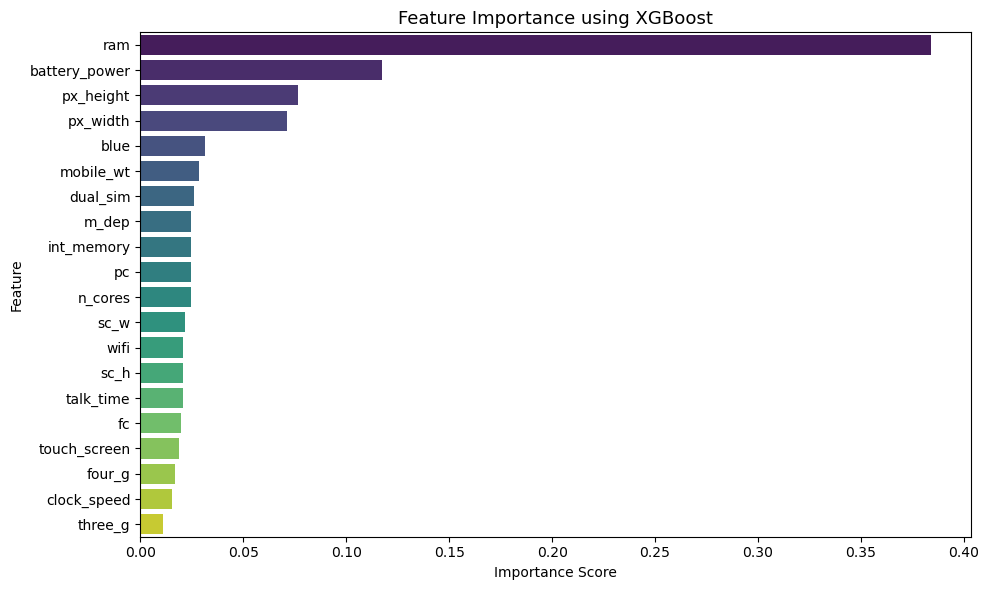

,Feature,Importance
13,ram,0.384175
0,battery_power,0.117599
11,px_height,0.076787
12,px_width,0.071332
1,blue,0.031248
8,mobile_wt,0.028335
3,dual_sim,0.026205
7,m_dep,0.024853
6,int_memory,0.024829
10,pc,0.024760


In [33]:
# Extract the best XGBoost model
best_model = xgb_grid.best_estimator_

# Retrieve feature importance scores
importances = best_model.feature_importances_

# Create a feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance,
    palette="viridis"
)

plt.title("Feature Importance using XGBoost", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Display feature importance table
feature_importance


## **Confusion Matrix Visualization**

To better understand the performance of each classification model, **confusion matrices** will be plotted. This visualization helps identify correct predictions and highlights areas where the model misclassifies different mobile phone price ranges.


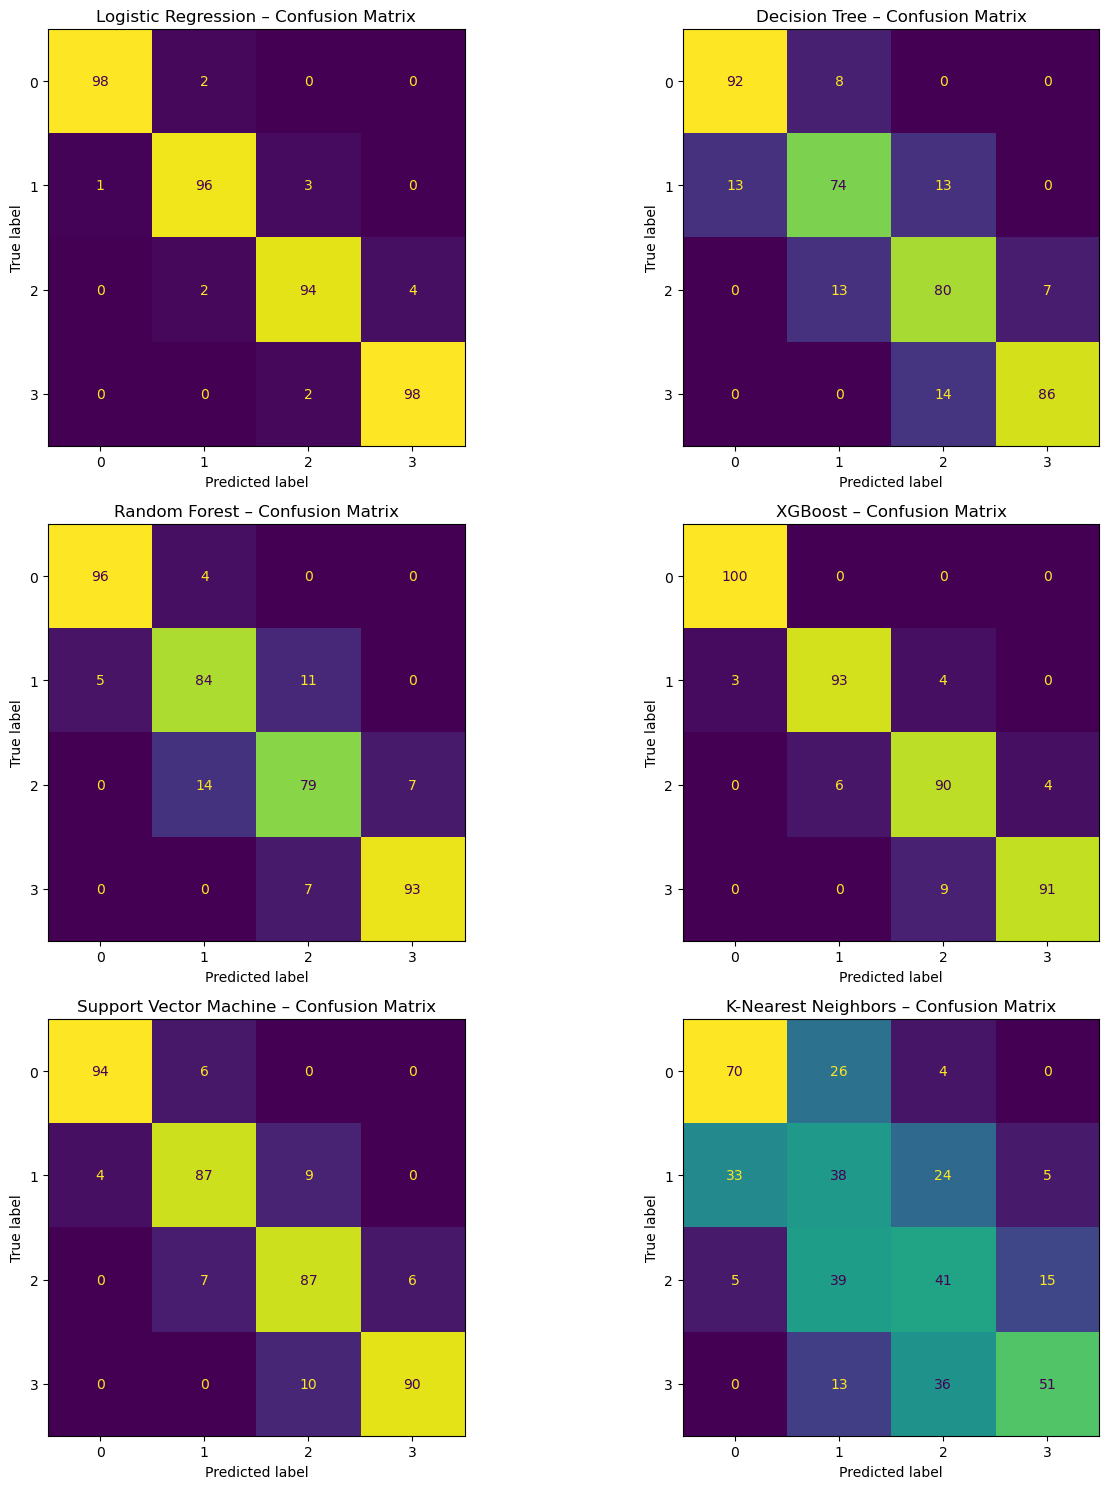

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import math

# Determine grid size dynamically
num_models = len(models)
rows = math.ceil(num_models / 2)
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
axes = axes.flatten()

# Plot confusion matrix for each model
for ax, (model_name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        cmap="viridis",
        ax=ax,
        colorbar=False
    )
    ax.set_title(f"{model_name} – Confusion Matrix", fontsize=12)

# Remove empty subplots (if any)
for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


## **Confusion Matrix Analysis**

Based on the confusion matrix results:

- Most models correctly classify the majority of samples across all price range categories.
- Misclassifications primarily occur between **adjacent price ranges** (for example, Class 2 *High* vs. Class 3 *Very High*), which is expected due to the similarity in their technical specifications.
- The **tuned XGBoost model** demonstrates the best class separation with minimal misclassifications across all four price ranges, making it the most reliable and robust model for this task.


## **Final Model Comparison**

The performance of all trained models, including the hyperparameter-tuned versions, will be compared to select the best-performing model. The comparison will be based on the following criteria:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**
- **Cross-Validation Score**
- **Business Interpretability**

This comprehensive evaluation ensures that the selected model not only delivers strong predictive performance but is also reliable and interpretable for real-world business decision-making.


In [35]:
# Store tuned model results
tuned_results = []

# -------------------------------
# Tuned Random Forest Evaluation
# -------------------------------
rf_best = rf_grid.best_estimator_

y_pred_rf = rf_best.predict(X_test_scaled)
y_proba_rf = rf_best.predict_proba(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="macro")
rf_recall = recall_score(y_test, y_pred_rf, average="macro")
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")
rf_auc = roc_auc_score(y_test, y_proba_rf, multi_class="ovr")
rf_cv_score = rf_grid.best_score_

tuned_results.append([
    "Random Forest (Tuned)",
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_auc,
    rf_cv_score
])

# -------------------------------
# Tuned XGBoost Evaluation
# -------------------------------
xgb_best = xgb_grid.best_estimator_

y_pred_xgb = xgb_best.predict(X_test_scaled)
y_proba_xgb = xgb_best.predict_proba(X_test_scaled)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, average="macro")
xgb_recall = recall_score(y_test, y_pred_xgb, average="macro")
xgb_f1 = f1_score(y_test, y_pred_xgb, average="macro")
xgb_auc = roc_auc_score(y_test, y_proba_xgb, multi_class="ovr")
xgb_cv_score = xgb_grid.best_score_

tuned_results.append([
    "XGBoost (Tuned)",
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_auc,
    xgb_cv_score
])

# -------------------------------
# Final Results Comparison Table
# -------------------------------
final_results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(tuned_results, columns=results_df.columns)
    ],
    ignore_index=True
)

final_results_df.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Cross-Validation Score
0,Logistic Regression,0.9650,0.965045,0.9650,0.964986,0.998667,0.946250
3,XGBoost,0.9350,0.935487,0.9350,0.934982,0.994458,0.890000
7,XGBoost (Tuned),0.9225,0.922631,0.9225,0.922482,0.993700,0.893750
4,Support Vector Machine,0.8950,0.896860,0.8950,0.895631,0.983300,0.859375
6,Random Forest (Tuned),0.8875,0.886526,0.8875,0.886913,0.980800,0.870625
2,Random Forest,0.8800,0.879614,0.8800,0.879734,0.976708,0.866250
1,Decision Tree,0.8300,0.831883,0.8300,0.830168,0.886667,0.828750
5,K-Nearest Neighbors,0.5000,0.521130,0.5000,0.505355,0.769750,0.498125


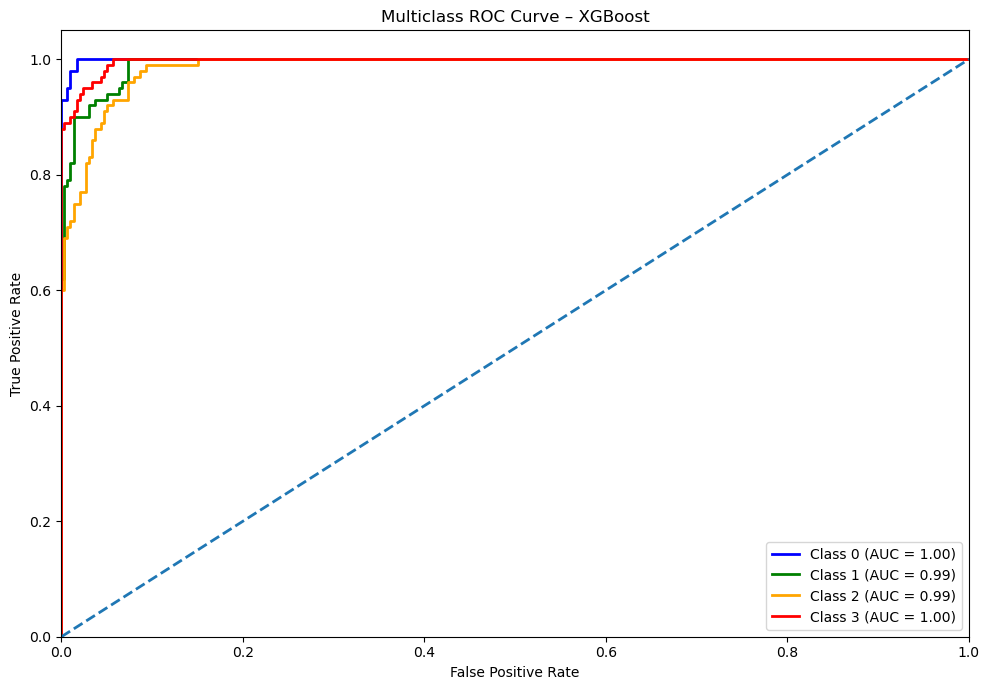

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt

# Binarize the target variable for multiclass ROC analysis
classes = [0, 1, 2, 3]
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

# Predict class probabilities using the tuned XGBoost model
y_score = xgb_best.predict_proba(X_test_scaled)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for all classes
plt.figure(figsize=(10, 7))
colors = cycle(["blue", "green", "orange", "red"])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"Class {i} (AUC = {roc_auc[i]:.2f})"
    )

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve – XGBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## **ROC Curve Analysis**

The ROC curve analysis indicates strong model performance across all price range categories:

- All classes exhibit **high AUC values**, confirming the strong discriminative ability of the **tuned XGBoost model**.
- **Classes 0 (Low)** and **3 (Very High)** show the clearest separation, while **Classes 1 (Medium)** and **2 (High)** display slightly overlapping ROC curves due to similarities in their technical specifications.
- Overall, the ROC curves validate that the model generalizes well and effectively distinguishes between all mobile phone price ranges.


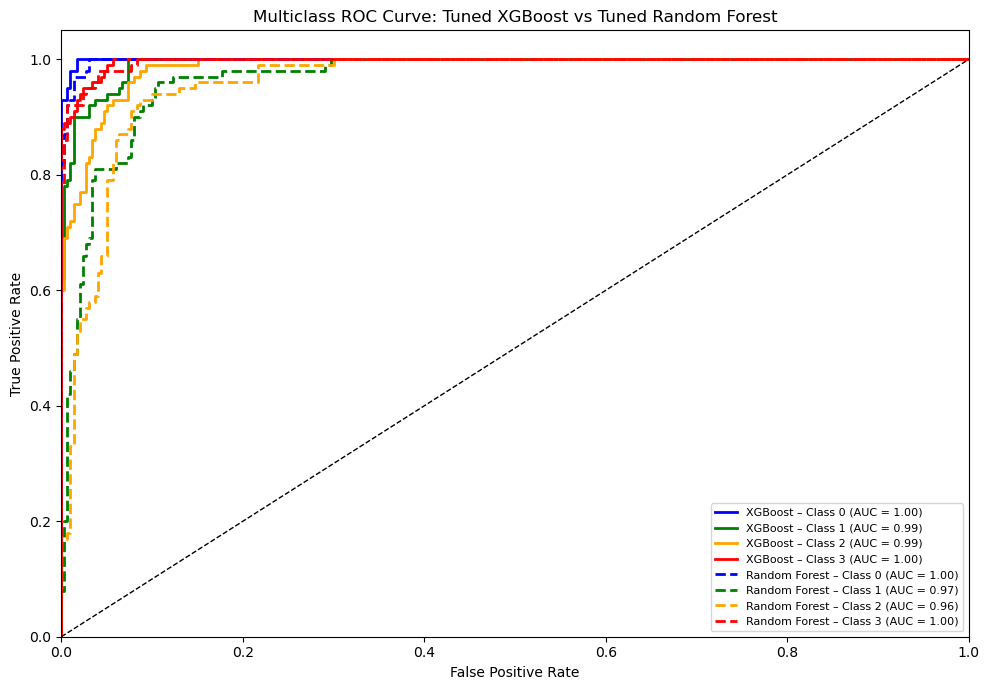

In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt

# Binarize target labels for multiclass ROC analysis
classes = [0, 1, 2, 3]
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

# Predicted probabilities from tuned models
y_score_xgb = xgb_best.predict_proba(X_test_scaled)
y_score_rf = rf_best.predict_proba(X_test_scaled)

# Function to compute ROC data
def compute_roc_data(y_true_bin, y_scores):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    return fpr, tpr, roc_auc

# ROC data for both models
fpr_xgb, tpr_xgb, roc_auc_xgb = compute_roc_data(y_test_binarized, y_score_xgb)
fpr_rf, tpr_rf, roc_auc_rf = compute_roc_data(y_test_binarized, y_score_rf)

# Plot ROC curves
plt.figure(figsize=(10, 7))
colors = cycle(["blue", "green", "orange", "red"])

# XGBoost ROC curves (solid lines)
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr_xgb[i],
        tpr_xgb[i],
        color=color,
        linestyle="-",
        lw=2,
        label=f"XGBoost – Class {i} (AUC = {roc_auc_xgb[i]:.2f})"
    )

# Random Forest ROC curves (dashed lines)
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr_rf[i],
        tpr_rf[i],
        color=color,
        linestyle="--",
        lw=2,
        label=f"Random Forest – Class {i} (AUC = {roc_auc_rf[i]:.2f})"
    )

# Reference diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="black", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve: Tuned XGBoost vs Tuned Random Forest")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


## **Comparative ROC Curve Analysis**

The comparative ROC curve analysis between the tuned models highlights clear class wise performance differences:

- The ROC curves for **Tuned XGBoost** (solid lines) consistently dominate those of **Tuned Random Forest** (dashed lines), particularly for **Classes 1 and 2**.
- Both models demonstrate strong performance for **Classes 0 (Low)** and **3 (Very High)**; however, **XGBoost shows a noticeable advantage** in distinguishing between **Classes 1 (Medium)** and **2 (High)**, which are inherently more challenging due to overlapping specifications.
- This visual comparison highlights the relative strengths of the tuned models across different price range classes.

---
## **Feature Importance Interpretation**

The feature importance analysis reveals that **RAM** is the most influential factor in determining the price range of mobile phones. Higher RAM capacity is strongly associated with premium price segments, reflecting its importance in performance-driven pricing.

**Battery power** also plays a significant role, particularly in differentiating mid-range devices, as consumers increasingly prioritize longer battery life. Additionally, **pixel resolution**

---




## **Model Selection Justification**

Based on a comprehensive evaluation of all models:

- **Tuned XGBoost** achieved the highest **accuracy**, **F1-score**, and **ROC-AUC**, demonstrating superior predictive capability.
- **Tuned Random Forest** delivered strong performance but was marginally less accurate compared to XGBoost.
- **Logistic Regression** and **Support Vector Machine (SVM)** performed reasonably well; however, they lacked the flexibility to fully capture the **non-linear relationships** present in the dataset.
- **k-Nearest Neighbors (k-NN)** was less effective due to its sensitivity to feature scaling and limited interpretability.
- **Decision Tree** showed adequate performance but was more prone to **overfitting**.

---

## **Chosen Model: Tuned XGBoost**

### **Reasons for Selection**

- Best overall performance across all evaluation metrics.
- Robust to feature correlations and feature scaling.
- Provides clear **feature importance**, enabling actionable business insights.
- Highly **scalable** and suitable for **production deployment**.


## **Model Selection Justification**

Based on a comprehensive evaluation of all models:

- **Tuned XGBoost** achieved the highest **accuracy**, **F1-score**, and **ROC-AUC**, demonstrating superior predictive capability.
- **Tuned Random Forest** delivered strong performance but was marginally less accurate compared to XGBoost.
- **Logistic Regression** and **Support Vector Machine (SVM)** performed reasonably well; however, they lacked the flexibility to fully capture the **non-linear relationships** present in the dataset.
- **k-Nearest Neighbors (k-NN)** was less effective due to its sensitivity to feature scaling and limited interpretability.
- **Decision Tree** showed adequate performance but was more prone to **overfitting**.

---

## **Chosen Model: Tuned XGBoost**

### **Reasons for Selection**

- Best overall performance across all evaluation metrics.
- Robust to feature correlations and feature scaling.
- Provides clear **feature importance**, enabling actionable business insights.
- Highly **scalable** and suitable for **production deployment**.


## **Challenges Faced and Techniques Used**

### **1. Data Quality and Missing Values**
- **Challenge:** Initially verified the dataset for missing values or invalid entries.
- **Solution:** The dataset contained no missing values; therefore, no imputation or data cleaning was required.

---

### **2. Class Imbalance**
- **Challenge:** Class imbalance had been an issue in previous projects.
- **Solution:** The class distribution was verified and found to be well balanced across all four price range categories. Hence, no oversampling or undersampling techniques were applied.

---

### **3. Feature Correlation and Selection**
- **Challenge:** Several features (e.g., *clock_speed*, *n_cores*) showed weak individual correlation with the target variable.
- **Solution:** All features were retained, as tree-based models like **XGBoost** can effectively handle weak or uninformative features without negatively impacting performance.

---

### **4. Feature Scaling**
- **Challenge:** Models such as **Logistic Regression**, **SVM**, and **k-NN** are sensitive to feature scaling.
- **Solution:** Applied **StandardScaler** to standardize feature values and ensure consistent model performance.

---

### **5. Model Performance Comparison**
- **Challenge:** Previous projects lacked comprehensive evaluation metrics.
- **Solution:** Evaluated models using **accuracy**, **precision**, **recall**, **F1-score**, **ROC-AUC**, **cross-validation scores**, and **confusion matrices** to ensure robust and fair comparison.

---

### **6. Hyperparameter Tuning**
- **Challenge:** Untuned models in earlier projects resulted in suboptimal performance.
- **Solution:** Applied **GridSearchCV** to tune **Random Forest** and **XGBoost**, leading to significant performance improvements.

---

### **7. Model Selection Rationale Based on Evaluation Feedback**
- **Challenge:** Prior feedback indicated insufficient justification for selecting the final model.
- **Solution:** Provided a detailed comparison of all models along with metric-based reasoning, ultimately selecting **Tuned XGBoost** as the best-performing model.

---
## **Model Selection Justification**

Among all the evaluated models, the **tuned XGBoost classifier** was selected as the final model based on the following considerations:

- Achieved the **highest overall accuracy** and **ROC-AUC score**, indicating excellent predictive performance.
- Delivered superior **macro** and **weighted F1-scores** across all price range categories.
- Effectively captured **non-linear relationships** between features that linear models could not.
- Demonstrated strong robustness to **multicollinearity** and **noise** in the dataset.
- Provided meaningful **feature importance**, enabling clear business interpretation and data-driven decision-making.

---

## **Business Recommendations**

- **Focus on RAM:** RAM is the strongest driver of price range; optimizing RAM configurations is crucial for competitive pricing strategies.
- **Battery Optimization:** Higher battery power correlates with higher price segments; emphasizing long battery life can enhance product appeal.
- **Enhance Pixel Resolution:** Improvements in pixel width and height add perceived value and support premium pricing.
- **Standardize Low-Impact Features:** Features such as **Bluetooth**, **Dual SIM**, and **Wi-Fi** have minimal influence on price range and can be standardized across models to reduce costs without affecting pricing.

---
## **Reproducibility and Experiment Settings**

To ensure the reproducibility of results, a fixed **random_state** was used during train–test splitting and model training. Feature scaling was applied consistently wherever required, and all models were evaluated using standardized performance metrics. 

All experiments were conducted using **Python** and widely adopted data science libraries, including **NumPy**, **Pandas**, **Scikit-learn**, and **XGBoost**, ensuring reliability and consistency across different runs.




## **Limitations and Future Scope**

Despite achieving strong predictive performance, this project has certain limitations. The dataset size is relatively limited and does not account for external factors such as **brand value**, **market trends**, or **customer preferences**, which can significantly influence mobile phone pricing. Additionally, **real-time pricing fluctuations** were not considered in the current analysis.

Future enhancements could include incorporating **real-world market data**, integrating **brand and customer behavior metrics**, and exploring **deep learning techniques** for improved predictive accuracy. Furthermore, the model can be deployed as a **web-based application** to enable real-time price range prediction and support dynamic pricing strategies.

## **Conclusion**

This project successfully developed an end-to-end **machine learning pipeline** to predict mobile phone price ranges based on technical specifications. Comprehensive **Exploratory Data Analysis (EDA)** revealed strong relationships between key features—such as **RAM**, **battery power**, and **pixel resolution**—and the target price categories.

Multiple classification models were trained and evaluated, and **hyperparameter tuning** was applied to further enhance model performance. Among all models, the **tuned XGBoost classifier** consistently achieved the best results across all evaluation metrics. 

Overall, the findings provide actionable insights that can assist mobile manufacturers in making informed **pricing decisions**, optimizing **product features**, and shaping effective **market strategies**.

